
# Предсказание следующего товара

Построить простую рекомендательную систему, которая предсказывает следующий товар, с которым взаимодействует пользователь, на основе истории его просмотров.

Предоставляется синтетический датасет e-commerce с пользовательскими сессиями просмотра товаров. Каждая сессия — это **последовательность ID товаров**, которые один пользователь просмотрел по порядку. **Каждая сессия содержит не менее 3 товаров.** Товары в сессии **упорядочены по возрастанию времени** просмотра: первый элемент — самое раннее взаимодействие, последний — самое позднее.

`[17, 42, 8, 103, 42]
[5, 99, 203, 17]
[203, 17, 88, 42, 7, 19]
[11, 11, 42]
...`

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

# sessions — список списков целых чисел
print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]


## ШАГ 1
**Анализ данных**
1. Число сессий, число уникальных товаров, распределение длин сессий, частоты товаров и другие сводные показатели, которые покажутся полезными
2. Сделайте несколько графиков
3. Отметьте всё, что покажется необычным или заслуживающим внимания

#### Общая статистика

Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
Последняя сессия: [114, 335, 53, 54, 114, 395, 65, 247, 48, 233, 361, 250, 41, 302, 54, 293, 65, 335, 385, 65]
Самая длинная сессия: 20
Самая короткая сессия: 3
Средняя длина сессии: 10.5, стандартное отклонение: 5.9
Медианная длина сессии: 9.0


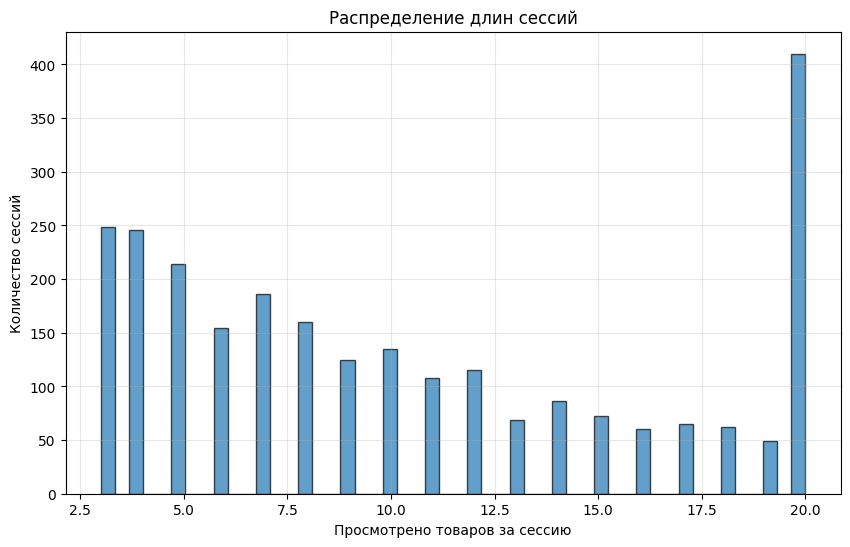

In [186]:
session_len = [len(session) for session in sessions]
lengths = [len(s) for s in sessions]
mean_len = sum(lengths) / len(lengths)
std_len = (sum((l - mean_len) ** 2 for l in lengths) / len(lengths)) ** 0.5
print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")
print(f"Последняя сессия: {sessions[-1]}")
print(f"Самая длинная сессия: {max(session_len)}")
print(f"Самая короткая сессия: {min(session_len)}")
print(f"Средняя длина сессии: {mean_len:.1f}, стандартное отклонение: {std_len:.1f}")
print(f"Медианная длина сессии: {np.median(session_len)}")
# График
'''
    X — сколько товаров посмотрели за одну сессию
    Y — сколько было таких сессий
'''
plt.figure(figsize=(10, 6))
plt.hist(session_len, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Просмотрено товаров за сессию')
plt.ylabel('Количество сессий')
plt.title('Распределение длин сессий')
plt.grid(True, alpha=0.3)
plt.show()

#### Статистика по товарам

Число уникальных товаров: 400
Всего просмотров за период: 26843
Среднее число взаимодействий на единицу товара: 67.1075
Число просмотров для товара N: [(0, 15), (1, 73), (2, 81)]
ID наиболее просматриваемых товаров и количество просмотров: [(54, 2914), (335, 1691), (53, 1223)]
ID наименее просматриваемых товаров и количество просмотров: [(184, 5), (305, 5), (118, 6)]


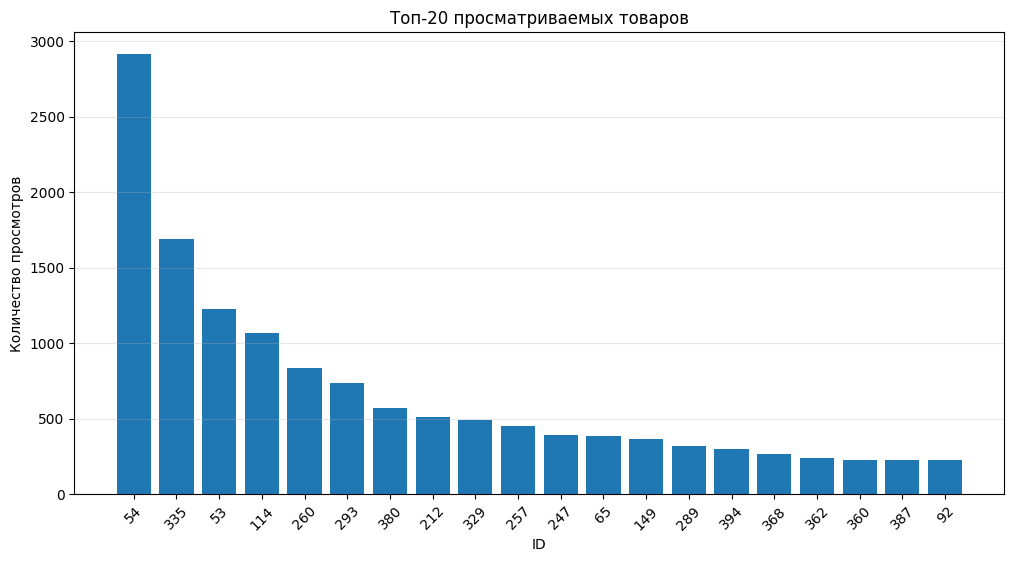

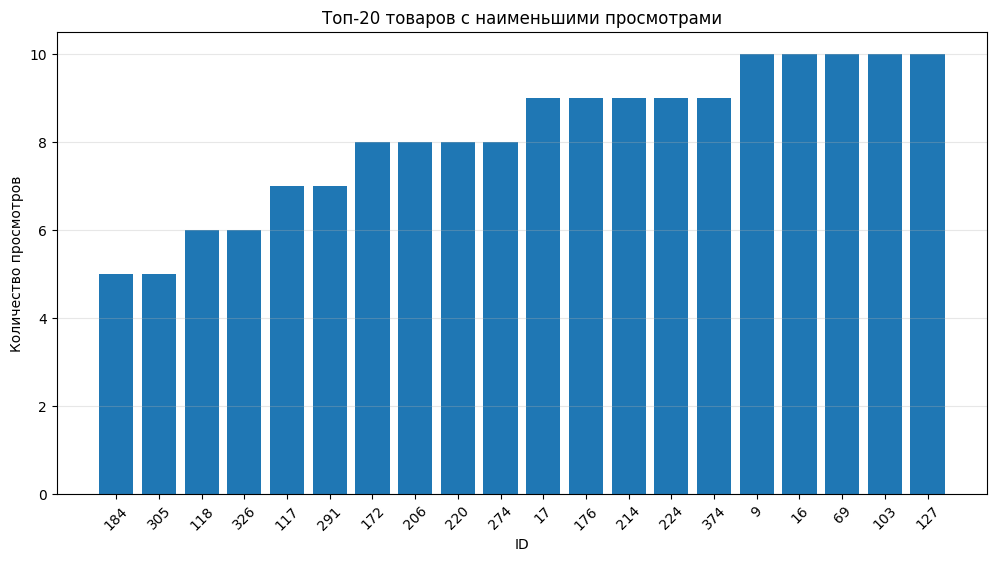

In [11]:
elems = []
for session in sessions:
    for elem in session:
        elems.append(elem)
unique = set(elems)
print(f"Число уникальных товаров: {len(unique)}") ## 0 - 399
# print(f"Длины сессий в течении дня: {[len(sessions) for sessions in sessions]}")
print(f"Всего просмотров за период: {len(elems)}")
print(f"Среднее число взаимодействий на единицу товара: {len(elems) / len(unique)}")
elem_view = {}
for session in sessions:
    for elem in session:
        if elem not in elem_view:
            elem_view[elem] = 1
        else:
            elem_view[elem] += 1
elem_view = sorted(elem_view.items(), key=lambda x: x[0])
print(f"Число просмотров для товара N: {elem_view[:3]}") ## первые 3
print(f"ID наиболее просматриваемых товаров и количество просмотров: {sorted(elem_view, key=lambda x: x[1], reverse=True)[:3]}") ## первые 3
print(f"ID наименее просматриваемых товаров и количество просмотров: {sorted(elem_view, key=lambda x: x[1])[:3]}") ## первые 3

# График 1
'''
    X — ID товара
    Y — сколько раз этот товар посмотрели
'''
sorted_by_views = sorted(elem_view, key=lambda x: x[1], reverse=True)
top_items = sorted_by_views[:20]
names, values = zip(*top_items)
plt.figure(figsize=(12, 6))
plt.bar(range(len(names)), values)
plt.xlabel('ID')
plt.ylabel('Количество просмотров')
plt.title('Топ-20 просматриваемых товаров')
plt.xticks(range(len(names)), names, rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# График 2
'''
    X — ID товара
    Y — сколько раз этот товар посмотрели
'''
sorted_by_views = sorted(elem_view, key=lambda x: x[1])
top_items = sorted_by_views[:20]
names, values = zip(*top_items)
plt.figure(figsize=(12, 6))
plt.bar(range(len(names)), values)
plt.xlabel('ID')
plt.ylabel('Количество просмотров')
plt.title('Топ-20 товаров c наименьшими просмотрами')
plt.xticks(range(len(names)), names, rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

#### Товары в начале и конце сессий

Товары с которых чаще всего начинается просмотр: [(54, 487), (335, 223), (53, 131), (114, 103), (260, 93)]
Товары на которых чаще всего заканчивается просмотр: [(54, 266), (335, 176), (114, 108), (53, 91), (293, 79)]


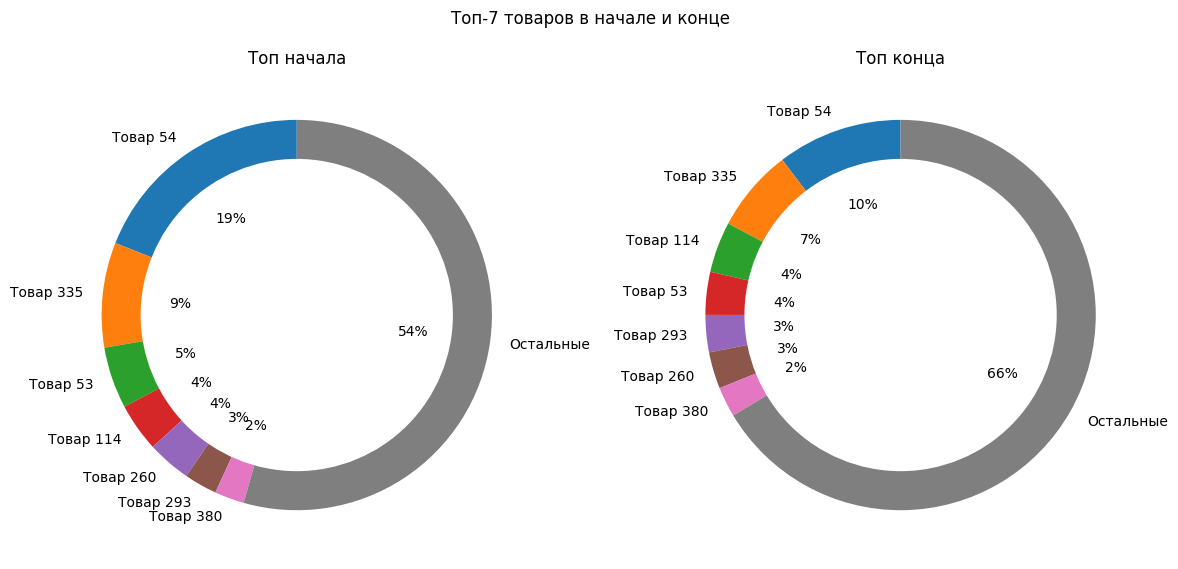

In [118]:
elem_start = {}
elem_end = {}
for session in sessions:
    if session[0] not in elem_start:
        elem_start[session[0]] = 1
    else:
        elem_start[session[0]] += 1
    if session[-1] not in elem_end:
        elem_end[session[-1]] = 1
    else:
        elem_end[session[-1]] += 1
elem_start = sorted(elem_start.items(), key=lambda x: x[1], reverse=True)
elem_end = sorted(elem_end.items(), key=lambda x: x[1], reverse=True)
print(f"Товары с которых чаще всего начинается просмотр: {elem_start[:5]}")
print(f"Товары на которых чаще всего заканчивается просмотр: {elem_end[:5]}")

# Pie chart
'''
    Левый график - товары, с которых начинают сессию. Для каждого товара своя доля (выделено цветом)
    Правый график - товары, на которых заканчивают сессию. Для каждого товара своя доля (выделено цветом)
    Серый сектор - все остальные товары (выделено серым цветом)
'''
sum_start = sum(x[1] for x in elem_start[7:])
sum_end = sum(x[1] for x in elem_end[7:])

start_data = [x[1] for x in elem_start[:7]] + [sum_start]
end_data = [x[1] for x in elem_end[:7]] + [sum_end]
start_labels = [f'Товар {x[0]}' for x in elem_start[:7]] + ['Остальные']
end_labels = [f'Товар {x[0]}' for x in elem_end[:7]] + ['Остальные']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.pie(start_data, labels=start_labels, autopct='%1.0f%%', startangle=90)
ax1.add_artist(plt.Circle((0, 0), 0.8, fc='white'))
ax1.set_title('Топ начала')

ax2.pie(end_data, labels=end_labels, autopct='%1.0f%%', startangle=90)
ax2.add_artist(plt.Circle((0, 0), 0.8, fc='white'))
ax2.set_title('Топ конца')

plt.suptitle('Топ-7 товаров в начале и конце')
plt.tight_layout()
plt.show()

#### Повторные просмотры

Всего повторных просмотров: 3780


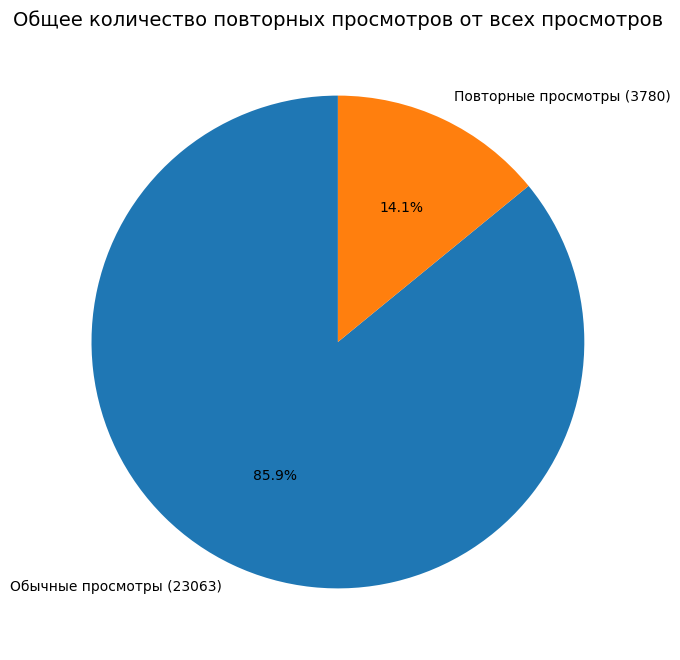

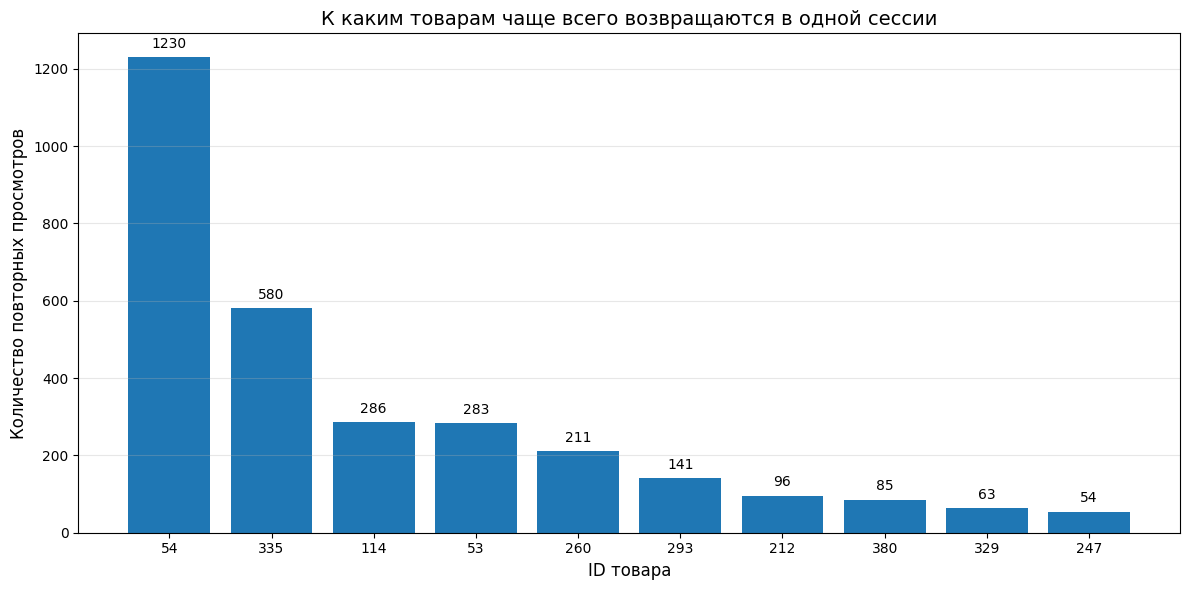

In [121]:
# повторный просмотр товаров
repeat = 0
for session in sessions:
    seen = set()
    for idx in session:
        if idx in seen:
            repeat += 1
        else:
            seen.add(idx)
print(f"Всего повторных просмотров: {repeat}")

# Pie chart
'''
    Синий сектор - обычные просмотры
    Красный сектор - повторные просмотры
'''
total_views = len(elems)
unique_views = total_views - repeat
plt.figure(figsize=(8, 8))
plt.pie([unique_views, repeat], labels=[f'Обычные просмотры ({unique_views})', f'Повторные просмотры ({repeat})'], autopct='%1.1f%%', startangle=90)
plt.title(f'Общее количество повторных просмотров от всех просмотров', fontsize=14)
plt.show()

# товары, на которые часто возвращаются
idx_repeat = {}
idx_all = {}
for session in sessions:
    seen = set()
    for idx in session:

        if idx not in idx_all: idx_all[idx] = 0
        idx_all[idx] += 1

        if idx in seen:
            if idx not in idx_repeat: idx_repeat[idx] = 0
            idx_repeat[idx] += 1

        else:
            seen.add(idx)

idx_repeat = sorted(idx_repeat.items(), key=lambda x: x[1], reverse=True)
# for item_id, repeats in item_repeats[:10]:
#     total = item_total[item_id]
#     print(f"Товар {item_id}: {repeats} повторов из {total} появлений")

# График
'''
    X - ID товара
    Y - сколько раз этот товар посмотрели повторно (вернулись к нему в той же сессии)
'''

top_repeats = idx_repeat[:10]
items = [str(item) for item, _ in top_repeats]
repeats_count = [count for _, count in top_repeats]

plt.figure(figsize=(12, 6))
plt.bar(items, repeats_count)
plt.xlabel('ID товара', fontsize=12)
plt.ylabel('Количество повторных просмотров', fontsize=12)
plt.title('Топ-10 товаров, к которым чаще всего возвращаются в одной сессии', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')

for i, (idx, count) in enumerate(top_repeats):
    plt.text(i, count + max(repeats_count)*0.02, str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Анализ позиций товара (на примере товара 54 - наиболее часто встречающийся)

Товар 54:
Всего появлений: 2914
Средняя позиция: 6.8
Минимальная позиция: 1
Максимальная позиция: 20


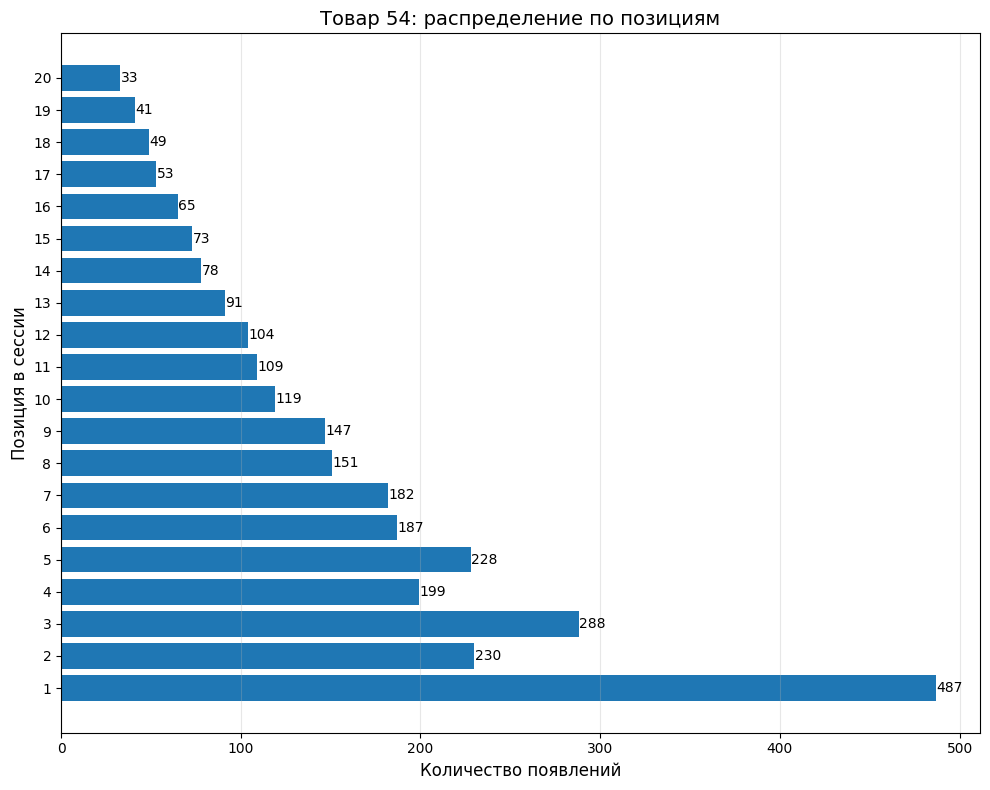

In [14]:
# на каких позициях чаще появляется какой-либо товар (для примера возьмем 54)
idx_pos = {}
for session in sessions:
    for pos, idx in enumerate(session):
        if idx not in idx_pos:
            idx_pos[idx] = []
        idx_pos[idx].append(pos + 1)

idx_ex = 54

if idx_ex in idx_pos:
    positions = idx_pos[idx_ex]
    avg_pos = sum(positions) / len(positions)
    print(f"Товар {idx_ex}:")
    print(f"Всего появлений: {len(positions)}")
    print(f"Средняя позиция: {avg_pos:.1f}")
    print(f"Минимальная позиция: {min(positions)}")
    print(f"Максимальная позиция: {max(positions)}")
    pos_counter = {}
    for p in positions:
        if p not in pos_counter:
            pos_counter[p] = 0
        pos_counter[p] += 1
    # sorted_pos = sorted(pos_counter.items(), key=lambda x: x[0])
    # print(f"Распределение по позициям (позиция: сколько раз):")
    # for pos, count in sorted_pos:
    #     print(f"Позиция {pos}: {count} раз(а)")
else:
    print(f"Товар {idx_ex} не найден")

# График
'''
    Y = позиция, где встречался товар
    X = сколько раз
'''
if idx_ex in idx_pos:
    positions = idx_pos[idx_ex]
    avg_pos = sum(positions) / len(positions)
    pos_counter = {}

    for p in positions:
        pos_counter[p] = pos_counter.get(p, 0) + 1

    sorted_pos = sorted(pos_counter.items())
    positions_list = [p for p, _ in sorted_pos]
    counts_list = [c for _, c in sorted_pos]

    plt.figure(figsize=(10, 8))
    bars = plt.barh(positions_list, counts_list)
    plt.yticks(positions_list, [str(p) for p in positions_list])
    plt.xlabel('Количество появлений', fontsize=12)
    plt.ylabel('Позиция в сессии', fontsize=12)

    for bar, count in zip(bars, counts_list):
        plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=10)

    plt.title(f'Товар {idx_ex}: распределение по позициям', fontsize=14)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

#### Цепочки товаров (цепочка из 2 и 3 товаров)

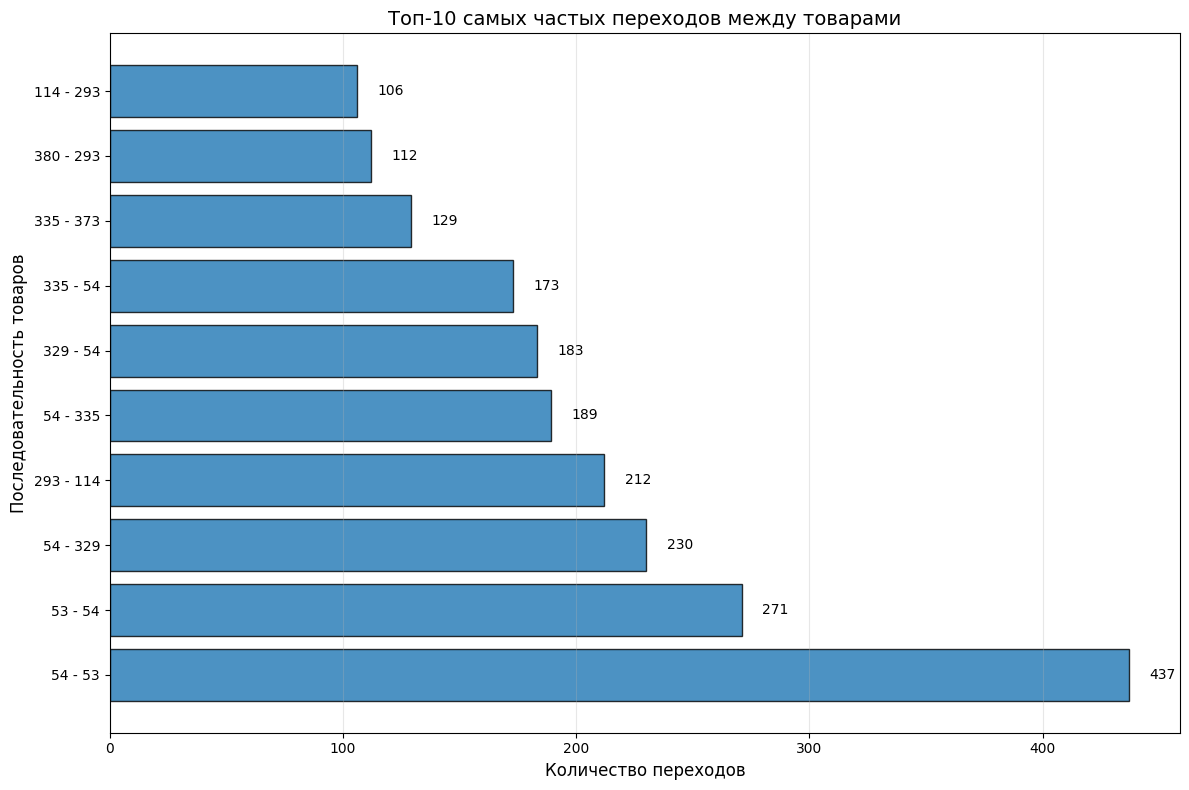

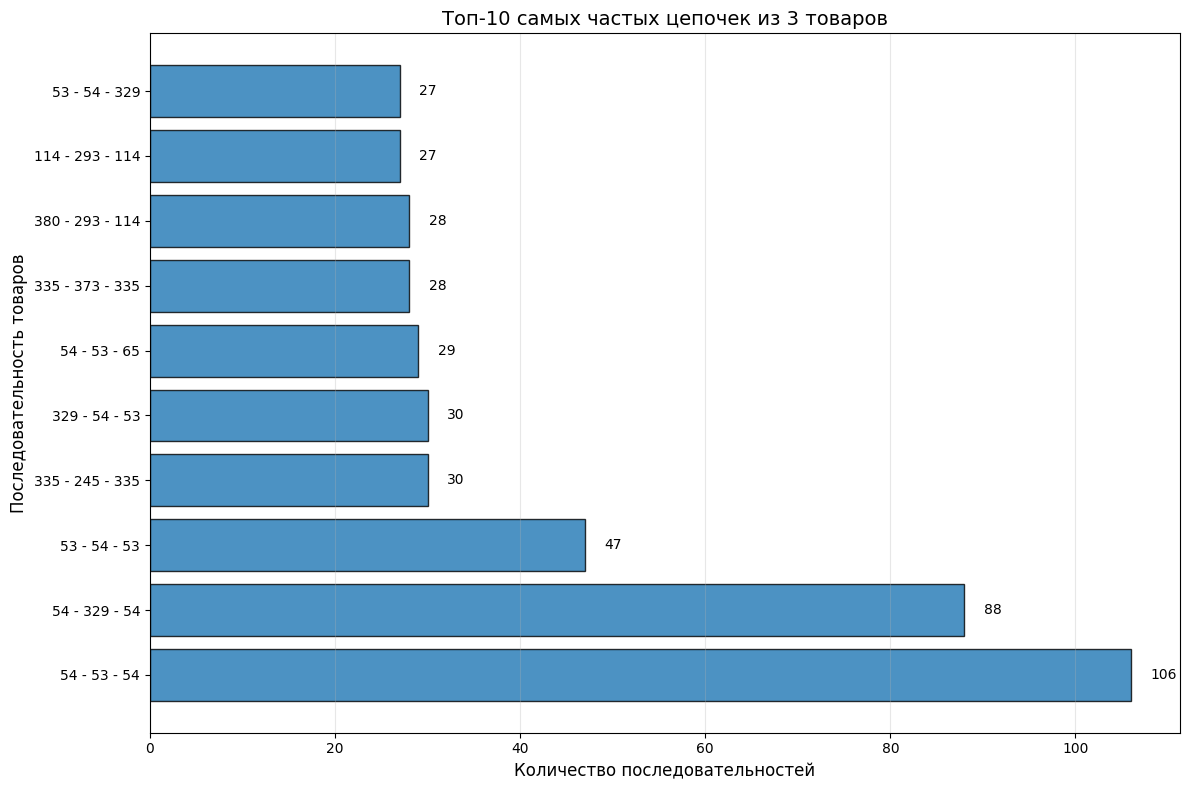

In [130]:
# цепочки из 2 товаров
pairs = {}
for session in sessions:
    for i in range(len(session) - 1):
        pair = (session[i], session[i+1])
        if pair not in pairs:
            pairs[pair] = 0
        pairs[pair] += 1

sorted_pairs = sorted(pairs.items(), key=lambda x: x[1], reverse=True)
# print("Топ-10 пар товаров (A -> B):")
# for pair, count in sorted_pairs[:10]:
#     print(f"{pair[0]} -> {pair[1]}: {count}")
# print("\n")

# График
'''
    Y - последовательность перехода между парой
    X - сколько раз такая пара встретилась
'''

top10_pairs = sorted_pairs[:10]
pair_labels = [f"{pair[0]} - {pair[1]}" for pair, _ in top10_pairs]
pair_counts = [count for _, count in top10_pairs]

plt.figure(figsize=(12, 8))
plt.barh(pair_labels, pair_counts, edgecolor='black', alpha=0.8)
plt.xlabel('Количество переходов', fontsize=12)
plt.ylabel('Последовательность товаров', fontsize=12)
plt.title('Топ-10 самых частых переходов между товарами', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
for i, (pair, count) in enumerate(top10_pairs):
    plt.text(count + max(pair_counts)*0.02, i, str(count), va='center', fontsize=10)
plt.tight_layout()
plt.show()

# цепочки из 3 товаров
trips = {}
for session in sessions:
    for i in range(len(session) - 2):
        trip = (session[i], session[i + 1], session[i + 2])
        if trip not in trips:
            trips[trip] = 0
        trips[trip] += 1

sorted_triplets = sorted(trips.items(), key=lambda x: x[1], reverse=True)
# print(f"Топ-10 цепочек из 3 товаров (A -> B -> C):")
# for triplet, count in sorted_triplets[:10]:
#     print(f"{triplet[0]} -> {triplet[1]} -> {triplet[2]}: {count}")

# График
'''
    Y - последовательность перехода между тройкой
    X - сколько раз такая тройка встретилась
'''

top10_triplets = sorted_triplets[:10]
triplet_labels = [f"{t[0]} - {t[1]} - {t[2]}" for t, _ in top10_triplets]
triplet_counts = [count for _, count in top10_triplets]

plt.figure(figsize=(12, 8))
plt.barh(triplet_labels, triplet_counts, edgecolor='black', alpha=0.8)
plt.xlabel('Количество последовательностей', fontsize=12)
plt.ylabel('Последовательность товаров', fontsize=12)
plt.title('Топ-10 самых частых цепочек из 3 товаров', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')

for i, (trip, count) in enumerate(top10_triplets):
    plt.text(count + max(triplet_counts)*0.02, i, str(count), va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Товары, встречающиеся вместе в одной сессии

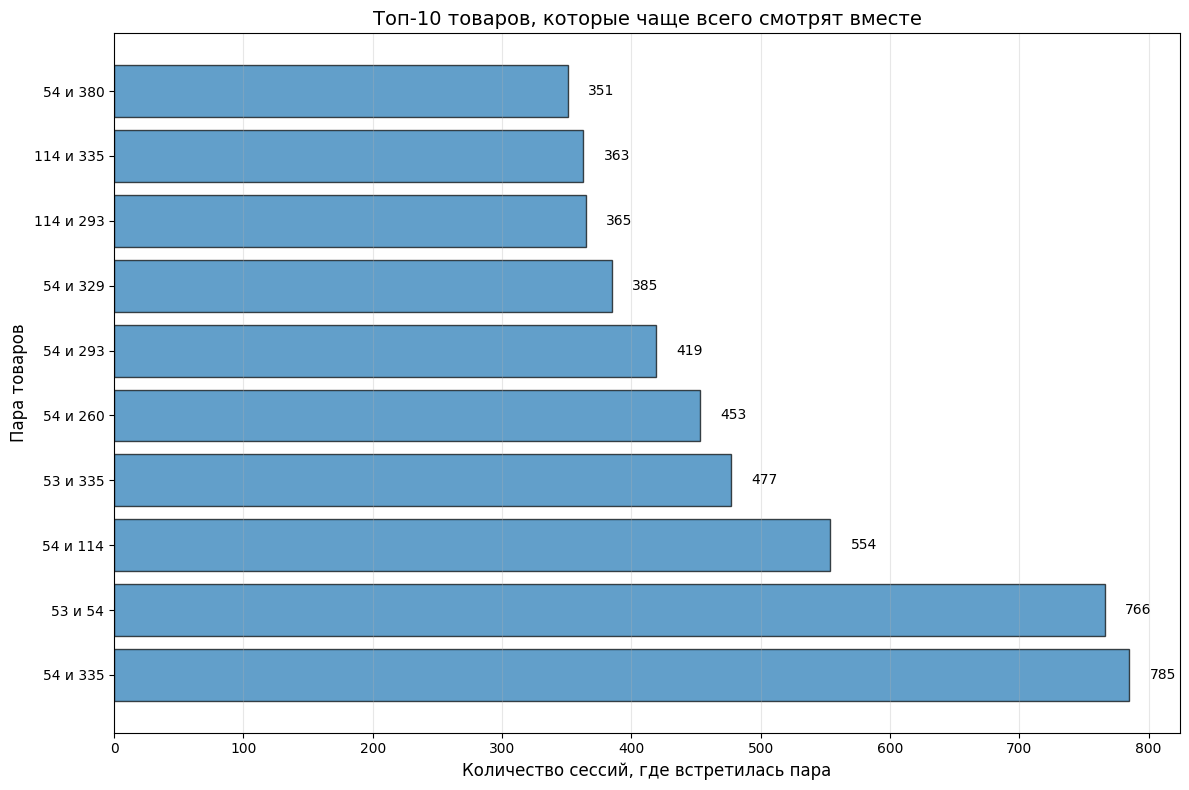

In [132]:
couple = {}
for session in sessions:
    uniq = list(set(session))
    for i in range(len(uniq)):
        for j in range(i + 1, len(uniq)):
            pair = tuple(sorted([uniq[i], uniq[j]]))
            if pair not in couple:
                couple[pair] = 0
            couple[pair] += 1

sorted_couple = sorted(couple.items(), key=lambda x: x[1], reverse=True)
# print(f"\nТоп-10 товаров которые чаще всего встречаются вместе в сессии:")
# for pair, count in sorted_together[:10]:
#     print(f"{pair[0]} и {pair[1]}: {count} сессий")

# График
'''
    Y - пара товаров
    X - сколько раз пара встретилась
'''

top10 = sorted_couple[:10]
pair_labels = [f"{pair[0]} и {pair[1]}" for pair, _ in top10]
pair_counts = [count for _, count in top10]

plt.figure(figsize=(12, 8))
plt.barh(pair_labels, pair_counts, edgecolor='black', alpha=0.7)
plt.xlabel('Количество сессий, где встретилась пара', fontsize=12)
plt.ylabel('Пара товаров', fontsize=12)
plt.title('Топ-10 товаров, которые чаще всего смотрят вместе', fontsize=14)
plt.grid(True, alpha=0.3, axis='x')
for i, (pair, count) in enumerate(top10):
    plt.text(count + max(pair_counts)*0.02, i, str(count), va='center', fontsize=10)
plt.tight_layout()
plt.show()

#### Карточки товаров, которые просматривали 1 раз (тест провален)

In [ ]:
# товары которые встречаются только 1 раз за всё время
# idx_uniq = {}
# for session in sessions:
#     for id_ in session:
#         if id_ not in idx_uniq:
#             idx_uniq[id_] = 0
#         idx_uniq[id_] += 1
#
# once_items = [item for item, count in idx_uniq.items() if count == 1]
#
# print(f"Товаров, встречающихся только 1 раз: {len(once_items)} из {len(idx_uniq)}")
## таких товаров не оказалось

#### Одинаковые сессии

In [134]:
# сессии-клоны
session_tuples = {}
for i, session in enumerate(sessions):
    t = tuple(session)
    if t not in session_tuples:
        session_tuples[t] = []
    session_tuples[t].append(i)

clones = {k: v for k, v in session_tuples.items() if len(v) > 1}
print(f"\nПолностью одинаковые: {len(clones)} групп")
for session_tuple, indices in list(clones.items()):
    print(f"Сессия {list(session_tuple)} повторяется {len(indices)} раз")


Полностью одинаковые: 1 групп
Сессия [54, 329, 54] повторяется 2 раз


#### Кластеры по наборам товаров

In [148]:
clusters = {}
for session in sessions:
    key = tuple(sorted(set(session)))
    if key not in clusters:
        clusters[key] = 0
    clusters[key] += 1
sorted_clusters = sorted(clusters.items(), key=lambda x: len(x[0]), reverse=True)
print(f"\nГрупп одинаковых наборов товаров: {len(clusters)}")
for items, count in sorted_clusters[:10]:
    print(f"{list(items)}: {count} раз")


Групп одинаковых наборов товаров: 2553
[10, 42, 53, 54, 65, 78, 83, 186, 240, 267, 281, 329, 333, 335, 347, 356, 358, 376, 381, 392]: 1 раз
[5, 22, 45, 53, 54, 65, 70, 154, 161, 190, 193, 257, 260, 333, 348, 358, 382, 383, 392, 394]: 1 раз
[1, 34, 53, 54, 106, 114, 142, 174, 205, 212, 260, 287, 289, 293, 296, 335, 348, 362, 367, 381]: 1 раз
[54, 55, 114, 135, 142, 149, 161, 193, 202, 212, 218, 231, 257, 260, 293, 335, 357, 360, 380, 394]: 1 раз
[12, 25, 53, 54, 111, 114, 129, 144, 149, 163, 260, 276, 328, 329, 335, 376, 379, 380, 382, 396]: 1 раз
[13, 31, 41, 64, 114, 147, 157, 163, 233, 243, 247, 257, 260, 281, 287, 293, 303, 311, 335, 379]: 1 раз
[10, 39, 54, 92, 122, 149, 157, 183, 193, 212, 231, 236, 247, 260, 264, 305, 354, 376, 392, 394]: 1 раз
[13, 39, 54, 86, 103, 122, 145, 257, 260, 261, 281, 335, 336, 342, 354, 360, 385, 387, 394]: 1 раз
[18, 53, 54, 98, 105, 126, 144, 146, 156, 188, 219, 237, 246, 256, 289, 335, 336, 373, 379]: 1 раз
[5, 30, 54, 64, 93, 100, 104, 108, 144, 

## ШАГ 2
**Train/test split**

Разбейте данные по схеме из раздела «Разбиение train / test»: в каждой сессии последний товар — тестовая цель, всё до него — обучающая история. Будьте готовы объяснить, почему случайное разбиение для таких данных не подходит.

In [147]:
def train_test_split( sessions: list[list[int]], ) -> tuple[list[list[int]], list[int]]:
    '''
    Разбиение сессий на train и test.

    Для каждой сессии:
      - все товары кроме последнего становятся
        обучающей сессией
      - последний товар становится тестовой целью

    Возвращаемые списки выровнены по индексу:
    test_targets[i] — товар, который нужно
    предсказать по train_sessions[i] как истории.

    Parameters
    ----------
    sessions : list of lists of ints
        Каждый вложенный список — одна сессия ID
        товаров, упорядоченная по времени.
        Все сессии содержат не менее 3 товаров.

    Returns
    -------
    train_sessions : list of lists of ints
        Сессии для обучения (исходные без последнего товара).
    test_targets : list of ints
        Следующий товар для предсказания по каждой сессии.
    '''
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets
import json
sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))

train_sessions, test_targets = train_test_split(sessions)

print(f"Для сессии {sessions[0]}:\n")
print(f"• Обучающая часть: {train_sessions[0]}")
print(f"• Тестовая цель: {test_targets[0]}")

Для сессии [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]:

• Обучающая часть: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341]
• Тестовая цель: 293


Наибольшее значение имеют события до тестовой цели и их порядок. При случайном выборе цели(если мы берем иные элементы - из середины, из начала и тд) модель заглядывает в будущее, и оценка становится нереалистичной, так как на момент предсказания нам доступно только прошлое, но последующие действия пользователя неизвестны.

## ШАГ 3
**Граф переходов**

На обучающих данных постройте граф, где вершины — товары, а рёбра — переходы между соседними товарами в сессии. Посчитайте `P(j | i)` — вероятность того, что сразу после i будет просмотрен j. Продумайте обработку редких или не встретившихся переходов.

In [146]:
pairs = {}
total = {}

for s in train_sessions:
    for i in range(len(s) - 1):
        a, b = s[i], s[i + 1]
        if a not in pairs:
            pairs[a] = {}
            total[a] = 0
        if b not in pairs[a]:
            pairs[a][b] = 0
        pairs[a][b] += 1
        total[a] += 1

pr = {}
for a, bs in pairs.items():
    pr[a] = {}
    for b, cnt in bs.items():
        pr[a][b] = cnt / total[a]

# print(probs)

top_items = sorted(total.items(), key=lambda x: x[1], reverse=True)[:30]
top_ids = [item for item, _ in top_items]

print("Граф переходов:")
print("ID товара -> ID товара (вероятность)")
alpha = 0.001 # редкий переход
for a in top_ids:
    if a in pr:
        top_trans = sorted(pr[a].items(), key=lambda x: x[1], reverse=True)[:3]
        parts = []
        for b, p in top_trans:
            if p < alpha:
                parts.append(f"{b} (P(i|j) мала)")
            else:
                parts.append(f"{b} ({p:.3f})")
        print(f"{a:>4} -> {', '.join(parts)}")
    else:
        print(f"{a:>4} -> (нет переходов)")

print(f"Всего вершин: {len(pr)}, всего рёбер: {sum(len(v) for v in pairs.values())}")

Граф переходов:
ID товара -> ID товара (вероятность)
  54 -> 53 (0.169), 329 (0.087), 335 (0.071)
 335 -> 54 (0.111), 373 (0.087), 245 (0.053)
  53 -> 54 (0.244), 65 (0.070), 335 (0.067)
 114 -> 293 (0.108), 380 (0.102), 54 (0.089)
 260 -> 149 (0.105), 92 (0.078), 54 (0.078)
 293 -> 114 (0.314), 380 (0.082), 54 (0.082)
 380 -> 293 (0.224), 114 (0.204), 54 (0.079)
 212 -> 362 (0.099), 387 (0.097), 54 (0.082)
 329 -> 54 (0.409), 53 (0.073), 335 (0.055)
 257 -> 54 (0.090), 273 (0.061), 385 (0.048)
  65 -> 54 (0.237), 53 (0.136), 329 (0.054)
 247 -> 266 (0.083), 54 (0.067), 233 (0.064)
 149 -> 260 (0.280), 161 (0.083), 54 (0.059)
 289 -> 368 (0.185), 287 (0.077), 54 (0.050)
 394 -> 257 (0.166), 54 (0.097), 39 (0.073)
 368 -> 289 (0.143), 54 (0.062), 57 (0.054)
 362 -> 212 (0.254), 387 (0.122), 54 (0.056)
 338 -> 54 (0.260), 53 (0.088), 65 (0.083)
 360 -> 281 (0.094), 54 (0.078), 335 (0.056)
 387 -> 212 (0.285), 362 (0.084), 54 (0.067)
  92 -> 260 (0.114), 149 (0.114), 54 (0.091)
 245 -> 33

## ШАГ 04
**Рекомендательная модель**
По последнему товару в сессии возвращайте топ-10 кандидатов, отранжированных по вероятности перехода. Корректно обработайте случай, когда последний товар ни разу не встречался при обучении.

In [180]:
## сначала хотела сделать сравнение с переходами двоек и троек элементов + веса(графики были в первом пункте), сделав, поняла, что получилось хуже в плане предсказаний, что проигрывает сл модели
def recommend(train_sessions, k=10, pair_w=1.0, trip_w=1.8, decay=0.75):
    all_pairs = {}
    all_trips = {}

    for s in train_sessions:
        for i in range(len(s) - 1):
            a = s[i]
            b = s[i + 1]
            if a not in all_pairs:
                all_pairs[a] = {}
            if b not in all_pairs[a]:
                all_pairs[a][b] = 0
            all_pairs[a][b] += 1

        for i in range(len(s) - 2):
            key = (s[i], s[i + 1])
            c = s[i + 2]
            if key not in all_trips:
                all_trips[key] = {}
            if c not in all_trips[key]:
                all_trips[key][c] = 0
            all_trips[key][c] += 1

    popular = [item for item, _ in top_items]
    result = []
    for s in train_sessions:
        scores = {}
        L = len(s)

        for pos in range(L):
            item = s[pos]
            weight = (decay ** (L - pos - 1)) if L > 1 else 1.0
            if item in pairs:
                for cand, cnt in pairs[item].items():
                    if cand not in scores:
                        scores[cand] = 0
                    scores[cand] += weight * pair_w * cnt

        for i in range(L - 1):
            key = (s[i], s[i + 1])
            weight = (decay ** (L - i - 2)) if L > 1 else 1.0
            if key in all_trips:
                for cand, cnt in all_trips[key].items():
                    if cand not in scores:
                        scores[cand] = 0
                    scores[cand] += weight * trip_w * cnt

        for item in s:
            scores.pop(item, None)

        candidates = [item for item, score in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

        seen = set(candidates)
        for item in popular:
            if len(candidates) >= k:
                break
            if item not in seen and item not in s:
                candidates.append(item)
                seen.add(item)

        result.append(candidates[:k])

    return result
#
# all_recommendations = recommend(train_sessions)
# improved_hits = sum(1 for i in range(len(test_targets)) if test_targets[i] in all_recommendations[i])
# print(f"{improved_hits} попаданий")

## эта модель показала результат намного лучше
def recommend_model(last, k = 10):
    if last in pr and pr[last]:
        candidate = sorted(pr[last].items(), key=lambda x: x[1], reverse=True)
        answ = [item for item, _ in candidate]
    else:
        answ = []
    # дополняем до k самыми популярными товарами -повторы -last_item
    seen = set(answ)
    for item, _ in top_items:
        if item not in seen and item != last:
            answ.append(item)
            seen.add(item)
        if len(answ) >= k:
            break

    return answ[:k]

base_recs = [recommend_model(s[-1]) for s in train_sessions]
cnt_yes = 0
cnt_no = 0
for i in range(len(test_targets)):
    if test_targets[i] in base_recs[i]:
        cnt_yes += 1
    else:
        cnt_no += 1
print(f"{cnt_yes} попаданий / {cnt_no} промахов")

1319 попаданий / 1246 промахов


## ШАГ 05
**Оценка качества**
Оцените модель на тесте по метрике Hit@10. Сравните с бейзлайном «10 самых популярных товаров». Если ваша модель не обходит бейзлайн — выясните, почему.

In [171]:
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)


model = [recommend_model(session[-1]) for session in train_sessions]
hit_model = hit_at_k(model, test_targets)
print(f"Модель: {(hit_model * 100):.2f} %")

improved_recs = recommend(train_sessions)
hit_improved = hit_at_k(improved_recs, test_targets)
print(f"Неэффективная модель: {hit_improved*100:.2f} %")

baseline = [[item for item, cnt in top_items][:10] for _ in test_targets]
hit_baseline = hit_at_k(baseline, test_targets)
print(f"Бейзлайн: {(hit_baseline * 100):.2f} %")


Модель: 51.42 %
Неэффективная модель: 33.72 %
Бейзлайн: 38.40 %
